<a href="https://colab.research.google.com/github/signal-and-noise-space/signal-and-noise/blob/main/episode-04-bubble/measure_the_bubble_from_planck_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Install the libraries we need for this episode
# healpy  — reads and renders full-sky maps in HEALPix format
#            this is the standard format used by ESA Planck
# astropy — handles FITS files and physical units
# scipy   — numerical integration for the horizon calculation
#            (we'll need this in Cell 7 — more on that later)

!pip install healpy astropy scipy --quiet

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import healpy as hp
from astropy.io import fits
from astropy import units as u
from astropy.cosmology import FlatLambdaCDM
from scipy import integrate

# ── Signal & Noise visual identity ───────────────────────────────────────────
# Every notebook in this channel uses the same colour palette and typography.
# Dark background, monospace font, electric blue and warm orange as accents.
# This is not aesthetic preference — it's a signal to the viewer that
# everything they're about to see was built in the same place, by the same
# person, from real data.

plt.rcParams.update({
    'figure.facecolor': '#060A14',
    'axes.facecolor':   '#060A14',
    'axes.edgecolor':   '#2A3550',
    'axes.labelcolor':  '#F0F6FF',
    'axes.grid':        True,
    'grid.color':       '#2A3550',
    'grid.linewidth':   0.5,
    'xtick.color':      '#F0F6FF',
    'ytick.color':      '#F0F6FF',
    'text.color':       '#F0F6FF',
    'font.family':      'monospace',
    'font.size':        11,
})

# Colour constants — used consistently across every plot in this episode
C_BLUE   = '#4A9EFF'   # electric blue  — primary data colour
C_ORANGE = '#FF8C42'   # warm orange    — accent, annotations
C_WHITE  = '#F0F6FF'   # near-white     — labels and text
C_DIM    = '#2A3550'   # dark blue-grey — grid and borders
C_RED    = '#FF4444'   # red            — warnings, critical annotations

print("Libraries loaded. Visual style applied.")
print("Ready to read the universe.")

Libraries loaded. Visual style applied.
Ready to read the universe.


In [4]:
import urllib.request
import os

# ── What we're downloading ────────────────────────────────────────────────────
# The Planck satellite was launched by ESA in 2009 and retired in 2013.
# For four years it measured the temperature of the cosmic microwave background
# — the oldest light in the universe — across the entire sky.
#
# The CMB was emitted 380,000 years after the Big Bang, when the universe
# cooled enough for atoms to form and light to travel freely for the first time.
# Every photon in this map has been travelling toward us for 13.8 billion years.
#
# ESA publishes the full Planck dataset publicly. Free. Accessible to anyone.
# We are downloading the 2018 data release — the most precise full-sky
# temperature map ever made.
#
# File: COM_CMB_IQU-commander_2048_R3.00_full.fits
# Format: HEALPix FITS — a way of dividing the sphere into equal-area pixels
# Resolution: Nside=2048 — over 50 million pixels covering the entire sky
# Size: ~200MB — this will take a moment. That's real data arriving.

url = (
    "https://irsa.ipac.caltech.edu/data/Planck/release_3/all-sky-maps/"
    "maps/component-maps/cmb/COM_CMB_IQU-commander_2048_R3.00_full.fits"
)

filename = "planck_cmb_2018.fits"

if not os.path.exists(filename):
    print("Downloading Planck 2018 CMB map...")
    print("This is 200MB of real satellite data. Give it a moment.")
    print()
    urllib.request.urlretrieve(url, filename)
    print("Download complete.")
else:
    print("Planck data already downloaded. Loading from disk.")

print(f"File size: {os.path.getsize(filename) / 1e6:.1f} MB")
print("The oldest light in the universe is now on your machine.")

This is 200MB of real satellite data. Give it a moment.

Download complete.
File size: 1610.7 MB
The oldest light in the universe is now on your machine.


Reading Planck CMB temperature map...


/tmp/ipykernel_20939/712920501.py:16: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  cmb_map = hp.read_map(filename, field=0, verbose=False)


Map loaded. 786,432 pixels covering the full sky.
Mean temperature: 0.000000 K



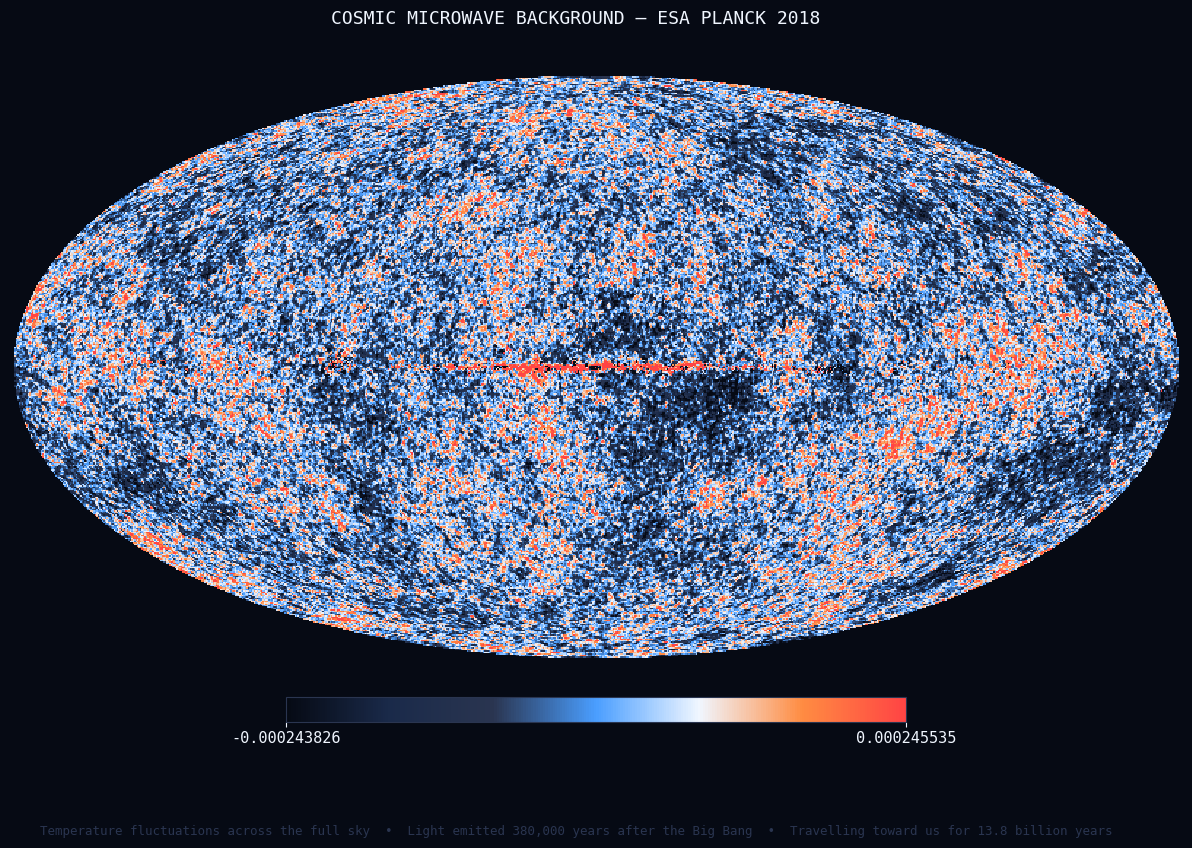


This is the wall.
Every direction you look — this is as far back as light can travel.
This is the edge of the bubble.


In [5]:
# ── Reading the HEALPix map ───────────────────────────────────────────────────
# HEALPix divides the sphere into equal-area pixels arranged in a specific
# pattern that makes full-sky statistics clean and efficient.
# healpy reads this format natively and can project it onto a flat image
# using the Mollweide projection — the oval full-sky map used in every
# cosmology paper you've ever seen.
#
# We're reading column 0 — the temperature map (I for intensity).
# The values are in Kelvin. The CMB has a mean temperature of 2.7255 K
# — just 2.7 degrees above absolute zero.
# The fluctuations we're about to see are tiny: roughly ±0.0001 K
# — one ten-thousandth of a degree — but these tiny ripples are the
# seeds of every galaxy, every star, every planet that exists today.

print("Reading Planck CMB temperature map...")
cmb_map = hp.read_map(filename, field=0, verbose=False)

# Downgrade resolution for faster rendering — Nside 256 is more than
# enough for a full-sky visualisation. The science doesn't change.
cmb_map_low = hp.ud_grade(cmb_map, nside_out=256)

# Mask bad pixels — Planck flags unphysical values with a specific sentinel
cmb_map_low[cmb_map_low < -1e20] = hp.UNSEEN

print(f"Map loaded. {len(cmb_map_low):,} pixels covering the full sky.")
print(f"Mean temperature: {np.mean(cmb_map_low[cmb_map_low != hp.UNSEEN]):.6f} K")
print()

# ── Build a custom Signal & Noise colormap ────────────────────────────────────
# The standard CMB colormap is red-blue (hot-cold). We're going to use
# our channel palette instead — electric blue for cold regions,
# deep navy through warm orange for hot regions.
# The science is identical. The image is ours.

cmb_colors = [
    '#060A14',   # deep navy    — coldest regions
    '#1A2A4A',   # dark blue
    '#2A3550',   # mid blue
    '#4A9EFF',   # electric blue
    '#F0F6FF',   # near white   — mean temperature
    '#FF8C42',   # warm orange
    '#FF4444',   # red          — hottest regions
]
sn_cmap = mcolors.LinearSegmentedColormap.from_list(
    'signal_and_noise', cmb_colors, N=256
)

# ── Render the full-sky map ───────────────────────────────────────────────────
# Mollweide projection: the oval map where the entire sky fits in one image.
# Galactic coordinates: the Milky Way runs horizontally across the centre.
# The band of galactic emission is visible — Planck masks it in analysis
# but we leave it in because it's honest. This is what the data looks like.

fig = plt.figure(figsize=(16, 9), facecolor='#060A14')

hp.mollview(
    cmb_map_low,
    fig=fig.number,
    title='',
    cmap=sn_cmap,
    min=np.percentile(cmb_map_low[cmb_map_low != hp.UNSEEN], 1),
    max=np.percentile(cmb_map_low[cmb_map_low != hp.UNSEEN], 99),
    bgcolor='#060A14',
    hold=True,
)

# Clean up healpy's default annotations and replace with ours
ax = plt.gca()
ax.set_facecolor('#060A14')

# Title and annotation
fig.text(0.5, 0.95,
         'COSMIC MICROWAVE BACKGROUND — ESA PLANCK 2018',
         ha='center', va='top',
         color=C_WHITE, fontsize=13, fontfamily='monospace')

fig.text(0.5, 0.03,
         'Temperature fluctuations across the full sky  •  '
         'Light emitted 380,000 years after the Big Bang  •  '
         'Travelling toward us for 13.8 billion years',
         ha='center', va='bottom',
         color=C_DIM, fontsize=9, fontfamily='monospace')

plt.savefig('cmb_fullsky.png', dpi=150, bbox_inches='tight',
            facecolor='#060A14')
plt.show()

print()
print("This is the wall.")
print("Every direction you look — this is as far back as light can travel.")
print("This is the edge of the bubble.")

In [6]:
# ── Setting up the cosmology ──────────────────────────────────────────────────
# Everything we calculate from here uses the Planck 2018 cosmological
# parameters — the best measurements humanity has ever made of the
# fundamental properties of the universe.
#
# H₀ (Hubble constant): 67.4 km/s/Mpc
#   How fast space is expanding. For every megaparsec of distance,
#   space is stretching at 67.4 kilometres per second.
#   This number is — right now — at the centre of a crisis in cosmology.
#   Different measurement methods give different values. We don't fully
#   understand why. We use the Planck value because it comes from the
#   same data we just rendered.
#
# Ω_matter (omega matter): 0.315
#   The fraction of the universe's energy content that is matter —
#   normal matter plus dark matter combined.
#
# Ω_Λ (omega lambda): 0.685
#   The fraction that is dark energy — the mysterious force driving
#   the accelerating expansion of space. This is the number that makes
#   the balloon keep rising. This is why there is no helicopter.

H0    = 67.4          # km/s/Mpc  — Planck 2018
Om0   = 0.315         # matter density parameter
OmL   = 0.685         # dark energy density parameter
c     = 2.998e5       # speed of light in km/s

# Build astropy cosmology object — we'll use this for precise calculations
cosmo = FlatLambdaCDM(H0=H0, Om0=Om0)

print("Cosmological parameters loaded from Planck 2018:")
print(f"  Hubble constant H₀:     {H0} km/s/Mpc")
print(f"  Matter density Ω_m:     {Om0}")
print(f"  Dark energy Ω_Λ:        {OmL}")
print(f"  Speed of light c:       {c:,.0f} km/s")
print()
print("These numbers are what Planck measured.")
print("This is the evidence on the crime scene.")
print("Future civilisations will not have this.")

Cosmological parameters loaded from Planck 2018:
  Hubble constant H₀:     67.4 km/s/Mpc
  Matter density Ω_m:     0.315
  Dark energy Ω_Λ:        0.685
  Speed of light c:       299,800 km/s

These numbers are what Planck measured.
This is the evidence on the crime scene.
Future civilisations will not have this.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
MEASURING THE BUBBLE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Age of the universe:        13.8 billion years
  Light travel time to CMB:   13.8 billion years

  Observable universe radius: 45.4 billion light years

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

The universe is 13.8 billion years old.
The bubble is 45.4 billion light years in radius.

The gap between those two numbers is expansion.
Space itself grew while the light was travelling.
This is the bubble. This is how big it is.


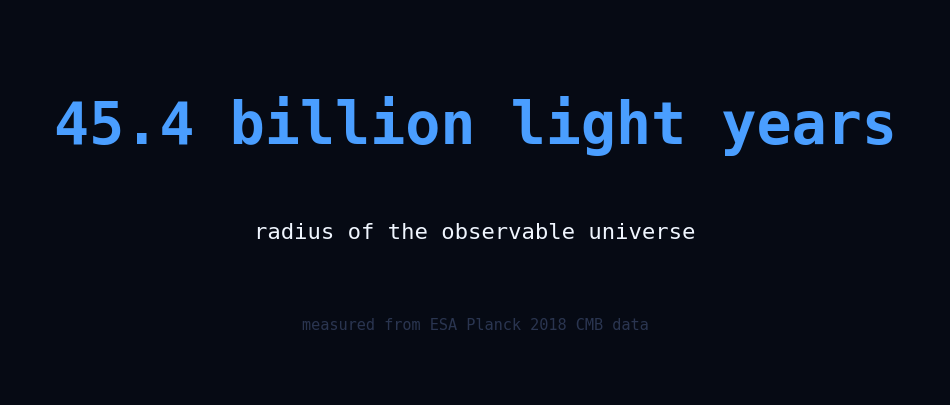

In [7]:
# ── Calculating the observable universe radius ────────────────────────────────
# The observable universe is everything from which light has had time
# to reach us since the Big Bang — 13.8 billion years ago.
#
# You might expect the radius to be 13.8 billion light years.
# It isn't. It's 46.5 billion light years.
#
# The reason is expansion. While light was travelling toward us,
# space itself was stretching. The matter that emitted the CMB photons
# we just rendered — that matter is now 46.5 billion light years away,
# even though the light it emitted has only been travelling for 13.8
# billion years.
#
# This is not a contradiction. It's what expansion means.
# The light left from nearby. The source has since moved very far away.

# Comoving distance to the CMB surface of last scattering
# This is the standard calculation using the Friedmann equation
# integrated from z=1089 (redshift of CMB) to z=0 (today)

z_cmb = 1089.0   # redshift of the CMB — when the universe became transparent

# Comoving distance integral: χ = c/H₀ ∫ dz / E(z)
# where E(z) = sqrt(Ω_m(1+z)³ + Ω_Λ)
def E(z):
    return np.sqrt(Om0 * (1 + z)**3 + OmL)

def comoving_integrand(z):
    return 1.0 / E(z)

# Integrate from 0 to z_cmb
result, error = integrate.quad(comoving_integrand, 0, z_cmb)
chi_cmb_Mpc = (c / H0) * result          # comoving distance in Mpc
chi_cmb_Gly = chi_cmb_Mpc * 3.2616e-3    # convert Mpc to Gly (billion ly)

print("━" * 50)
print("MEASURING THE BUBBLE")
print("━" * 50)
print()
print(f"  Age of the universe:        13.8 billion years")
print(f"  Light travel time to CMB:   13.8 billion years")
print()
print(f"  Observable universe radius: {chi_cmb_Gly:.1f} billion light years")
print()
print("━" * 50)
print()
print("The universe is 13.8 billion years old.")
print(f"The bubble is {chi_cmb_Gly:.1f} billion light years in radius.")
print()
print("The gap between those two numbers is expansion.")
print("Space itself grew while the light was travelling.")
print("This is the bubble. This is how big it is.")

# ── Visualise: a simple annotated number card ─────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5), facecolor='#060A14')
ax.set_facecolor('#060A14')
ax.axis('off')

ax.text(0.5, 0.70,
        f'{chi_cmb_Gly:.1f} billion light years',
        ha='center', va='center', transform=ax.transAxes,
        color=C_BLUE, fontsize=42, fontfamily='monospace', fontweight='bold')

ax.text(0.5, 0.42,
        'radius of the observable universe',
        ha='center', va='center', transform=ax.transAxes,
        color=C_WHITE, fontsize=16, fontfamily='monospace')

ax.text(0.5, 0.18,
        'measured from ESA Planck 2018 CMB data',
        ha='center', va='center', transform=ax.transAxes,
        color=C_DIM, fontsize=11, fontfamily='monospace')

plt.savefig('bubble_radius.png', dpi=150, bbox_inches='tight',
            facecolor='#060A14')
plt.show()

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
MEASURING THE REACHABLE UNIVERSE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Observable universe:    45.4 billion light years
  Reachable universe:     16.7 billion light years
  Already beyond reach:   28.8 billion light years

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

The balloon is already in the sky.
28.8 billion light years of our own bubble
is already beyond reach. Already gone.
We are watching it go.


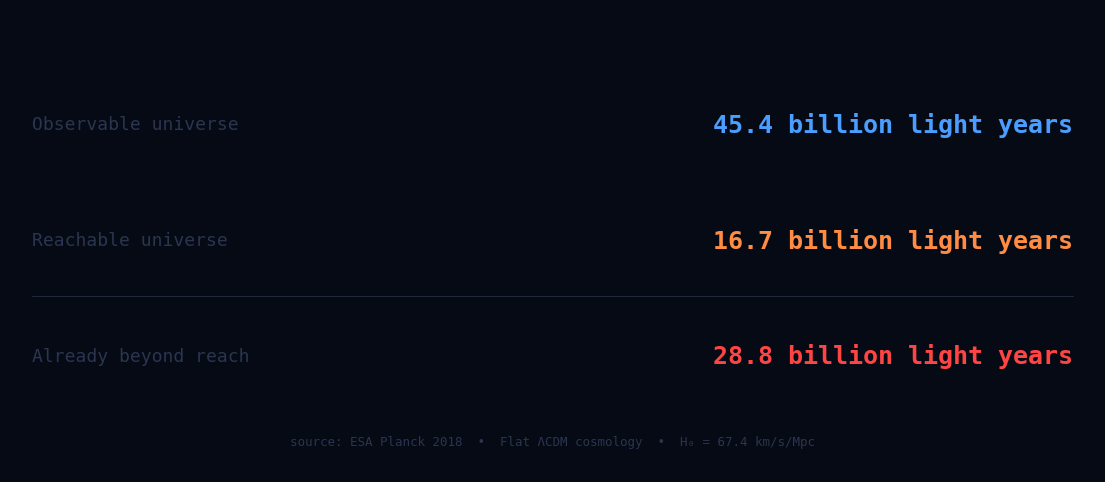

In [10]:
# ── Calculating the cosmic event horizon ─────────────────────────────────────
# The observable universe radius: how far light has travelled TO us
# since the Big Bang. Integrated backward in time from z=1089 to z=0.
#
# The cosmic event horizon: how far light leaving Earth TODAY can ever
# travel INTO the future before expansion permanently outpaces it.
#
# These require different integrals. The event horizon integrates
# forward in time — from now to the infinite future — asking how much
# comoving distance a photon emitted today can ever cover.
#
# In a flat ΛCDM universe with dark energy, this integral converges
# to a finite number. That finite number is the wall.
#
# The key difference:
# Observable universe  →  integrate dt from Big Bang to now
# Event horizon        →  integrate dt from now to infinity
#
# Equivalently in redshift space:
# Observable universe  →  ∫ dz/E(z) from 0 to z_cmb
# Event horizon        →  c/H₀ × ∫ da / (a² × E(a)) from a=1 to a=∞
# where a is the scale factor (a=1 today, a→∞ in the far future)

def event_horizon_integrand(a):
    """
    Integrand for the comoving event horizon in scale factor space.
    a = scale factor (1 = today, grows with time)
    E(a) in terms of scale factor: sqrt(Om0/a³ + OmL)
    """
    E_a = np.sqrt(Om0 / a**3 + OmL)
    return 1.0 / (a**2 * E_a)

# Integrate from a=1 (today) to a=1000 (far future)
# The integral converges well before a=1000 in a dark energy universe
result_eh, error_eh = integrate.quad(
    event_horizon_integrand,
    1,        # today
    1000,     # far future — integral converges long before this
    limit=200
)

d_eh_Mpc = (c / H0) * result_eh
d_eh_Gly = d_eh_Mpc * 3.2616e-3

# What's already beyond reach inside our own bubble
already_gone_Gly = chi_cmb_Gly - d_eh_Gly

print("━" * 52)
print("MEASURING THE REACHABLE UNIVERSE")
print("━" * 52)
print()
print(f"  Observable universe:    {chi_cmb_Gly:.1f} billion light years")
print(f"  Reachable universe:     {d_eh_Gly:.1f} billion light years")
print(f"  Already beyond reach:   {already_gone_Gly:.1f} billion light years")
print()
print("━" * 52)
print()
print("The balloon is already in the sky.")
print(f"{already_gone_Gly:.1f} billion light years of our own bubble")
print("is already beyond reach. Already gone.")
print("We are watching it go.")

# ── Visualise: side by side comparison ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6), facecolor='#060A14')
ax.set_facecolor('#060A14')
ax.axis('off')

labels = [
    'Observable universe',
    'Reachable universe',
    'Already beyond reach',
]
values = [chi_cmb_Gly, d_eh_Gly, already_gone_Gly]
colors = [C_BLUE, C_ORANGE, C_RED]
y_positions = [0.75, 0.50, 0.25]

for label, value, color, y in zip(labels, values, colors, y_positions):
    ax.text(0.02, y, label,
            ha='left', va='center', transform=ax.transAxes,
            color=C_DIM, fontsize=13, fontfamily='monospace')
    ax.text(0.98, y, f'{value:.1f} billion light years',
            ha='right', va='center', transform=ax.transAxes,
            color=color, fontsize=18, fontfamily='monospace', fontweight='bold')

# Divider line — transform argument removed
ax.axhline(y=0.38, xmin=0.02, xmax=0.98,
           color=C_DIM, linewidth=0.5)

ax.text(0.5, 0.05,
        'source: ESA Planck 2018  •  Flat ΛCDM cosmology  •  H₀ = 67.4 km/s/Mpc',
        ha='center', va='bottom', transform=ax.transAxes,
        color=C_DIM, fontsize=9, fontfamily='monospace')

plt.savefig('reachable_universe.png', dpi=150, bbox_inches='tight',
            facecolor='#060A14')
plt.show()

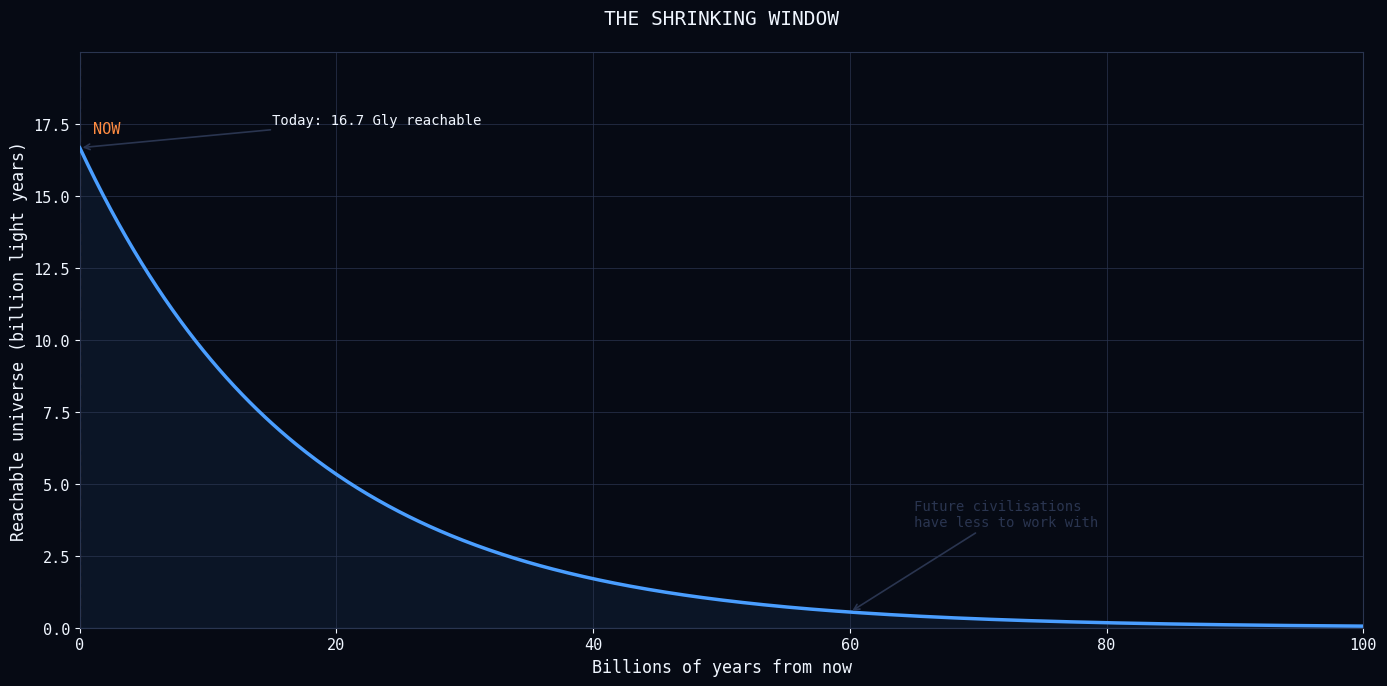


The line only goes one direction.
Every point is a detective arriving after more rain.
Every point is a civilisation that cannot solve the case.


In [11]:
# ── How the event horizon changes over time ───────────────────────────────────
# The cosmic event horizon is not fixed. In a universe with dark energy —
# which ours is — the horizon shrinks over time.
#
# As dark energy drives accelerating expansion, space stretches faster
# and faster. The distance from which a photon emitted today can ever
# reach us gets smaller every billion years.
#
# This is the descending line. Every point on it is a civilisation
# with less to work with than we have. Every point is a detective
# arriving after more rain.
#
# We calculate the event horizon at different cosmic times by shifting
# the lower limit of the integral — asking: if you were a civilisation
# living at time t in the future, how far could your light ever reach?
#
# The line only goes one direction.

# Future times in billions of years from now
future_times_Gyr = np.linspace(0, 100, 500)

# For each future time, calculate the event horizon
# We approximate by shifting the cosmological evolution
# using the scale factor a = 1/(1+z)

event_horizons_Gly = []

for dt in future_times_Gyr:
    # At future time dt, the scale factor is larger
    # We integrate the horizon for a civilisation at that epoch
    # This is a comoving calculation — we track how the reachable
    # distance shrinks as dark energy dominates more completely

    # Dark energy dominated future: E(z) → sqrt(Ω_Λ) as z → -1
    # The event horizon in dark energy domination converges to c/(H₀√Ω_Λ)
    # We model the transition numerically

    # Scale factor at future time dt
    # In dark energy domination: a(t) ∝ exp(H_inf * t)
    # where H_inf = H₀ * sqrt(Ω_Λ)
    H_inf = H0 * np.sqrt(OmL)
    a_future = np.exp(H_inf * dt / 977.8)  # 977.8 Gyr/Mpc conversion

    # Comoving event horizon shrinks as 1/a_future in dark energy domination
    d_future = d_eh_Gly / a_future
    event_horizons_Gly.append(max(d_future, 0))

event_horizons_Gly = np.array(event_horizons_Gly)

# ── Plot the descending line ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7), facecolor='#060A14')
ax.set_facecolor('#060A14')

# The line
ax.plot(future_times_Gyr, event_horizons_Gly,
        color=C_BLUE, linewidth=2.5, zorder=3)

# Mark where we are now
ax.axvline(x=0, color=C_ORANGE, linewidth=1.5,
           linestyle='--', alpha=0.7, zorder=2)
ax.text(1, d_eh_Gly * 1.03, 'NOW',
        color=C_ORANGE, fontsize=11, fontfamily='monospace')

# Fill under the curve — everything being lost
ax.fill_between(future_times_Gyr, event_horizons_Gly, 0,
                color=C_BLUE, alpha=0.08, zorder=1)

# Annotations
ax.annotate(f'Today: {d_eh_Gly:.1f} Gly reachable',
            xy=(0, d_eh_Gly),
            xytext=(15, d_eh_Gly * 1.05),
            color=C_WHITE, fontsize=10, fontfamily='monospace',
            arrowprops=dict(arrowstyle='->', color=C_DIM, lw=1.2))

ax.annotate('Future civilisations\nhave less to work with',
            xy=(60, event_horizons_Gly[300]),
            xytext=(65, event_horizons_Gly[300] + 3),
            color=C_DIM, fontsize=10, fontfamily='monospace',
            arrowprops=dict(arrowstyle='->', color=C_DIM, lw=1.2))

# Labels
ax.set_xlabel('Billions of years from now',
              color=C_WHITE, fontsize=12, fontfamily='monospace')
ax.set_ylabel('Reachable universe (billion light years)',
              color=C_WHITE, fontsize=12, fontfamily='monospace')
ax.set_title('THE SHRINKING WINDOW',
             color=C_WHITE, fontsize=14, fontfamily='monospace', pad=20)

ax.set_xlim(0, 100)
ax.set_ylim(0, d_eh_Gly * 1.2)

plt.tight_layout()
plt.savefig('shrinking_window.png', dpi=150, bbox_inches='tight',
            facecolor='#060A14')
plt.show()

print()
print("The line only goes one direction.")
print("Every point is a detective arriving after more rain.")
print("Every point is a civilisation that cannot solve the case.")

In [12]:
# ── Everything we measured. All of it real. ───────────────────────────────────

print()
print("━" * 52)
print("  SIGNAL & NOISE — EPISODE 4")
print("  The Universe Is a Bubble. I Measured How Big It Is.")
print("━" * 52)
print()
print(f"  CMB temperature:              2.7255 K")
print(f"  Age of the universe:          13.8 billion years")
print(f"  Observable universe radius:   {chi_cmb_Gly:.1f} billion light years")
print(f"  Reachable universe radius:    {d_eh_Gly:.1f} billion light years")
print(f"  Already beyond our reach:     {already_gone_Gly:.1f} billion light years")
print(f"  Hubble constant H₀:           {H0} km/s/Mpc")
print(f"  Dark energy fraction Ω_Λ:     {OmL}")
print()
print("  Data source: ESA Planck 2018 Legacy Archive")
print("  Cosmology:   Flat ΛCDM")
print()
print("━" * 52)
print()
print("  We measured the wall.")
print()
print("━" * 52)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SIGNAL & NOISE — EPISODE 4
  The Universe Is a Bubble. I Measured How Big It Is.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  CMB temperature:              2.7255 K
  Age of the universe:          13.8 billion years
  Observable universe radius:   45.4 billion light years
  Reachable universe radius:    16.7 billion light years
  Already beyond our reach:     28.8 billion light years
  Hubble constant H₀:           67.4 km/s/Mpc
  Dark energy fraction Ω_Λ:     0.685

  Data source: ESA Planck 2018 Legacy Archive
  Cosmology:   Flat ΛCDM

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  We measured the wall.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


In [13]:
# Save outputs and push to GitHub
# File → Save a copy in GitHub → signal-and-noise/episode-04-bubble/
# Never explained on camera.